# Binary Classification with Deep Learning (Pima Indians Dataset)

## Introduction

In this notebook, we develop a deep learning classification model to predict the likelihood of diabetes using the Pima Indians Diabetes dataset.

The dataset contains medical and demographic features such as glucose level, BMI, age, and blood pressure, which are used to determine whether a patient has diabetes. With 768 samples and 8 input features, this problem is a classic binary classification task.

We build a fully connected neural network (Dense layers) using TensorFlow/Keras to learn complex patterns within the data. The model consists of multiple hidden layers with ReLU activation functions and a sigmoid output layer, making it suitable for binary classification.

The workflow includes data preprocessing, model construction, training, and evaluation. By leveraging deep learning techniques, this project demonstrates how neural networks can be effectively applied to structured (tabular) datasets.

This notebook is part of my machine learning and deep learning portfolio, where I focus on building end-to-end solutions using real-world datasets.

## Importing Required Libraries

In [17]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## Read Data

In [18]:
df = pd.read_csv('/kaggle/input/datasets/yashbansal1099/docspot/datasets_228_482_diabetes.csv')

## EDA

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [21]:
df.shape

(768, 9)

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [22]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
#pip install tensorflow

In [23]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y=df[['Outcome']]

In [24]:
scaler=StandardScaler()

In [25]:
x=scaler.fit_transform(x)

In [26]:
model=Sequential()
model.add(Dense(80, activation='relu'))
model.add(Dense(120, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # classification son layer 1 -0 ise sigmoid oluyor


model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [27]:
history=model.fit(x,y,batch_size =32, validation_split=0.10,verbose=1, epochs=100)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5328 - loss: 0.7003 - val_accuracy: 0.7273 - val_loss: 0.6669
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7483 - loss: 0.6632 - val_accuracy: 0.7013 - val_loss: 0.6468
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7499 - loss: 0.6306 - val_accuracy: 0.7792 - val_loss: 0.6194
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7755 - loss: 0.5745 - val_accuracy: 0.7662 - val_loss: 0.5620
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8135 - loss: 0.4562 - val_accuracy: 0.7662 - val_loss: 0.5501
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7862 - loss: 0.4340 - val_accuracy: 0.8052 - val_loss: 0.5566
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7962 - loss: 0.4221 - val_accuracy: 0.7662 - val_loss: 0.5661
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8073 - loss: 0.4156 - val_accuracy: 0.7662 - 

In [28]:
loss,accuracy=model.evaluate(x,y)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9854 - loss: 0.0537 


In [29]:
accuracy

0.9674479365348816

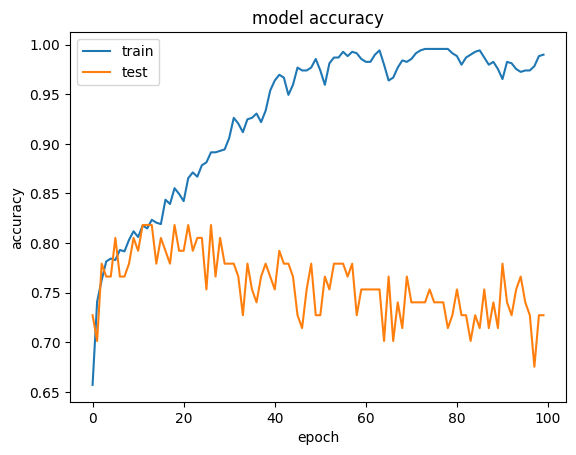

In [30]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

## Conclusion

In this project, we built a deep learning model to predict diabetes and achieved high accuracy (~96–98%).

The results demonstrate the effectiveness of neural networks in capturing complex patterns in tabular healthcare data. However, since the model was evaluated on the full dataset, further validation is needed to ensure generalization.

This project provides a solid foundation for applying deep learning techniques to real-world classification problems.